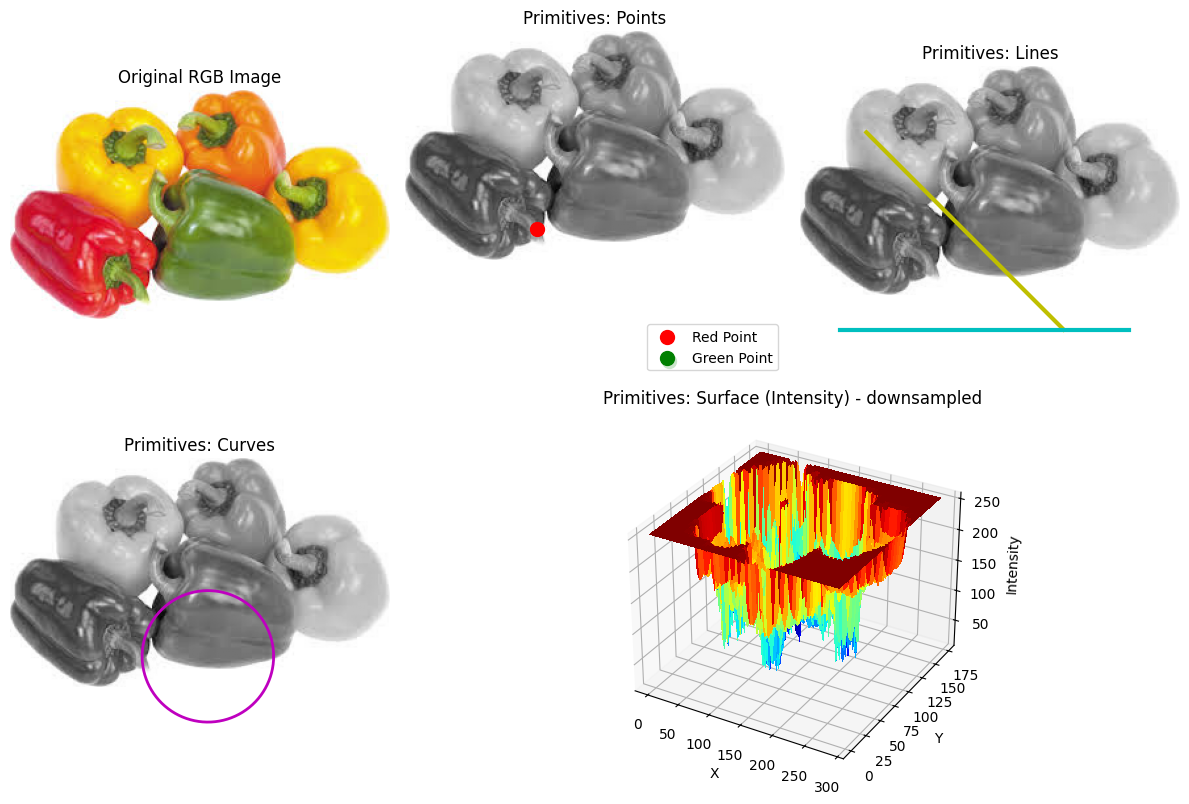

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read an in-built RGB image
img = cv2.imread(cv2.samples.findFile('peppers.jpeg'))
if img is None:
    raise FileNotFoundError("Image not found. Replace 'lena.jpg' with your own image file path.")

# Convert from BGR → RGB for correct display
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(12, 8))

# 1. Original RGB image
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title('Original RGB Image')
plt.axis('off')

# 2. Points (marking specific pixels)
plt.subplot(2, 3, 2)
plt.imshow(gray_img, cmap='gray')
plt.scatter(100, 150, c='r', s=100, label='Red Point')   # red point
plt.scatter(200, 250, c='g', s=100, label='Green Point') # green point
plt.title('Primitives: Points')
plt.legend(loc='lower right')
plt.axis('off')

# 3. Lines
plt.subplot(2, 3, 3)
plt.imshow(gray_img, cmap='gray')
plt.plot([50, 200], [50, 200], color='y', linewidth=3)   # diagonal line
plt.plot([30, 250], [200, 200], color='c', linewidth=3)  # horizontal line
plt.title('Primitives: Lines')
plt.axis('off')

# 4. Curves
plt.subplot(2, 3, 4)
plt.imshow(gray_img, cmap='gray')
theta = np.linspace(0, 2 * np.pi, 100)
x = 150 + 50 * np.cos(theta)
y = 150 + 50 * np.sin(theta)
plt.plot(x, y, color='m', linewidth=2)
plt.title('Primitives: Curves')
plt.axis('off')

# 5. Surfaces (3D intensity surface of grayscale image)
# 5. Surfaces (3D intensity surface of grayscale image)
ax = plt.subplot(2, 3, (5, 6), projection='3d')
X = np.arange(0, gray_img.shape[1])
Y = np.arange(0, gray_img.shape[0])
X, Y = np.meshgrid(X, Y)
Z = gray_img.astype(float)

# Downsample for faster plotting
ds = max(1, gray_img.shape[0] // 120)  # adjust divisor to trade speed vs detail
Xs = X[::ds, ::ds]
Ys = Y[::ds, ::ds]
Zs = Z[::ds, ::ds]

ax.plot_surface(Xs, Ys, Zs, cmap='jet', linewidth=0, antialiased=False)
ax.set_title('Primitives: Surface (Intensity) - downsampled')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Intensity')

plt.tight_layout()
plt.show()
